
# Demos curiosas para explicar CNN en clase (MNIST + CIFAR-10)

Cuaderno **paso a paso** (no interactivo) con mini-experimentos visuales para:
- entender **kernels/filtros**, **pooling/stride**, **receptive field**
- comprobar **(no) invariancias** (traslación, rotación)
- visualizar **explicabilidad** (occlusion map / Grad-CAM)
- ver efectos en **accuracy** (capacidad, pooling vs stride, tamaño de dataset)
- (educativo) ejemplo de **ataque adversarial FGSM** en MNIST

> Sugerencia de clase: ejecuta una sección, comenta lo que se ve, y luego pasa a la siguiente.

## 0) Setup

In [1]:

# !pip -q install tensorflow matplotlib pandas

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Opcional: XLA
try:
    tf.config.optimizer.set_jit(True)
except Exception:
    pass


2026-03-13 12:14:00.473177: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 12:14:00.784067: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-13 12:14:00.784087: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-03-13 12:14:00.829797: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-13 12:14:01.664841: W tensorflow/stream_executor/platform/de

TensorFlow: 2.10.0
GPUs: []


2026-03-13 12:14:02.853515: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-13 12:14:02.853946: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-13 12:14:02.854137: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-03-13 12:14:02.854308: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-03-13 12:14:02.854383: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Co

## 1) Utilidades de visualización

In [2]:

def show_img(img, title=None, cmap=None):
    plt.figure(figsize=(3,3))
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[...,0]
    plt.imshow(img, cmap=cmap)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

def show_row(images, titles=None, cmap=None, figsize=(14,3)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i, im in enumerate(images):
        plt.subplot(1, n, i+1)
        if im.ndim == 3 and im.shape[-1] == 1:
            im = im[...,0]
        plt.imshow(im, cmap=cmap)
        plt.axis("off")
        if titles is not None:
            plt.title(titles[i], fontsize=10)
    plt.tight_layout()
    plt.show()

def plot_history(history, title=None):
    if history is None:
        return
    h = history.history

    plt.figure(figsize=(6,4))
    if "loss" in h: plt.plot(h["loss"], label="train_loss")
    if "val_loss" in h: plt.plot(h["val_loss"], label="val_loss")
    plt.xlabel("epoch"); plt.ylabel("loss")
    if title: plt.title(title)
    plt.legend(); plt.show()

    if "accuracy" in h:
        plt.figure(figsize=(6,4))
        plt.plot(h["accuracy"], label="train_acc")
        if "val_accuracy" in h:
            plt.plot(h["val_accuracy"], label="val_acc")
        plt.xlabel("epoch"); plt.ylabel("accuracy")
        if title: plt.title(title)
        plt.legend(); plt.show()



# Parte A — MNIST (rápido y muy visual)

Entrenamos una CNN pequeña (pocas épocas + subset) y luego hacemos demos sobre:
- filtros aprendidos
- traslación / rotación
- occlusion sensitivity
- pooling vs stride
- overfitting (tamaño de dataset)
- adversarial FGSM (educativo)

## A1) Cargar MNIST

**Qué haremos:** Cargamos MNIST, normalizamos, creamos *train/val/test* y enseñamos algunos ejemplos.


Train: (50000, 28, 28, 1) (50000,)
Val  : (10000, 28, 28, 1) (10000,)
Test : (10000, 28, 28, 1) (10000,)


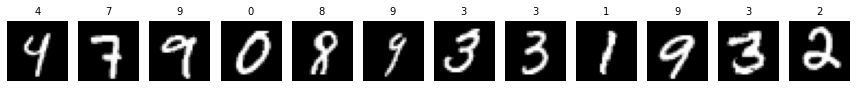

In [3]:

from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = (x_train.astype("float32") / 255.0)[..., None]  # (N,28,28,1)
x_test  = (x_test.astype("float32")  / 255.0)[..., None]

# split train/val
val_size = 10000
x_val, y_val = x_train[-val_size:], y_train[-val_size:]
x_tr,  y_tr  = x_train[:-val_size], y_train[:-val_size]

print("Train:", x_tr.shape, y_tr.shape)
print("Val  :", x_val.shape, y_val.shape)
print("Test :", x_test.shape, y_test.shape)

idx = np.random.default_rng(SEED).choice(len(x_tr), size=12, replace=False)
show_row([x_tr[i] for i in idx], [str(int(y_tr[i])) for i in idx], cmap="gray", figsize=(12,3))


## A2) Entrenar una CNN base (rápida)

**Qué haremos:** Entrenamos una CNN *baseline* rápida que usaremos en el resto de demos.


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv1 (Conv2D)              (None, 28, 28, 16)        160       
                                                                 
 pool1 (MaxPooling2D)        (None, 14, 14, 16)        0         
                                                                 
 conv2 (Conv2D)              (None, 14, 14, 32)        4640      
                                                                 
 pool2 (MaxPooling2D)        (None, 7, 7, 32)          0         
                                                                 
 flatten (Flatten)           (None, 1568)              0         
                                                                 
 dense (Dense)               (None, 64)                100416

2026-03-13 12:14:16.158661: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/3


2026-03-13 12:14:16.460052: W tensorflow/compiler/jit/mark_for_compilation_pass.cc:1780] (One-time warning): Not using XLA:CPU for cluster.

If you want XLA:CPU, do one of the following:

 - set the TF_XLA_FLAGS to include "--tf_xla_cpu_global_jit", or
 - set cpu_global_jit to true on this session's OptimizerOptions, or
 - use experimental_jit_scope, or
 - use tf.function(jit_compile=True).

To confirm that XLA is active, pass --vmodule=xla_compilation_cache=1 (as a
proper command-line flag, not via TF_XLA_FLAGS).


157/157 [==============================] - 3s 16ms/step - loss: 0.5660 - accuracy: 0.8484 - val_loss: 0.2089 - val_accuracy: 0.9444
Epoch 2/3
157/157 [==============================] - 2s 14ms/step - loss: 0.1516 - accuracy: 0.9568 - val_loss: 0.1272 - val_accuracy: 0.9624
Epoch 3/3
157/157 [==============================] - 2s 15ms/step - loss: 0.0945 - accuracy: 0.9726 - val_loss: 0.1037 - val_accuracy: 0.9700
MNIST test acc: 0.9702


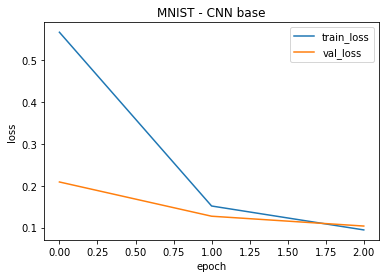

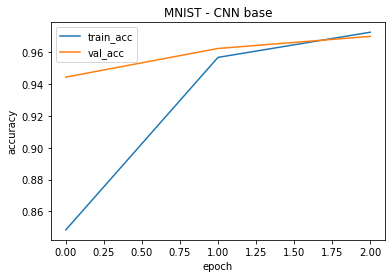

In [4]:

def build_mnist_cnn(filters=16, kernel=3, use_pool=True, use_stride_downsample=False):
    inp = keras.Input(shape=(28,28,1))

    x = layers.Conv2D(filters, kernel, padding="same", activation="relu", name="conv1")(inp)

    if use_stride_downsample:
        x = layers.Conv2D(filters, kernel, strides=2, padding="same", activation="relu", name="down1")(x)
    elif use_pool:
        x = layers.MaxPooling2D(name="pool1")(x)

    x = layers.Conv2D(filters*2, kernel, padding="same", activation="relu", name="conv2")(x)

    if use_stride_downsample:
        x = layers.Conv2D(filters*2, kernel, strides=2, padding="same", activation="relu", name="down2")(x)
    elif use_pool:
        x = layers.MaxPooling2D(name="pool2")(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(10, activation="softmax")(x)

    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

train_n = 20000
val_n   = 5000
x_tr_s, y_tr_s = x_tr[:train_n], y_tr[:train_n]
x_val_s, y_val_s = x_val[:val_n], y_val[:val_n]

mnist_model = build_mnist_cnn(filters=16, kernel=3, use_pool=True)
mnist_model.summary()

history = mnist_model.fit(
    x_tr_s, y_tr_s,
    validation_data=(x_val_s, y_val_s),
    epochs=3,
    batch_size=128,
    verbose=1
)

te_loss, te_acc = mnist_model.evaluate(x_test, y_test, verbose=0)
print("MNIST test acc:", round(float(te_acc), 4))
plot_history(history, title="MNIST - CNN base")


## A3) Filtros aprendidos en `conv1`

**Qué haremos:** Visualizamos los **filtros aprendidos** en la primera convolución para ver qué patrones detecta.


W shape: (3, 3, 1, 16) | b shape: (16,)


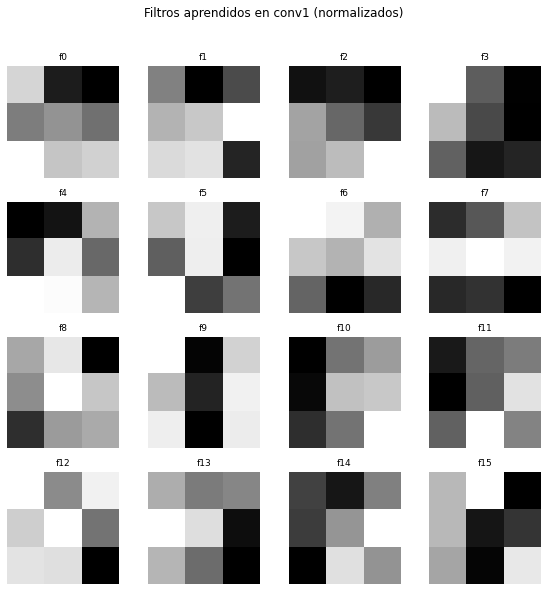

In [5]:

conv1 = mnist_model.get_layer("conv1")
W, b = conv1.get_weights()
print("W shape:", W.shape, "| b shape:", b.shape)

n_filters = W.shape[-1]
filters = []
for i in range(n_filters):
    f = W[...,0,i]
    f = f - f.min()
    if f.max() > 0:
        f = f / f.max()
    filters.append(f)

cols = int(math.ceil(math.sqrt(n_filters)))
rows = int(math.ceil(n_filters / cols))
plt.figure(figsize=(2*cols, 2*rows))
for i, f in enumerate(filters):
    plt.subplot(rows, cols, i+1)
    plt.imshow(f, cmap="gray")
    plt.axis("off")
    plt.title(f"f{i}", fontsize=9)
plt.suptitle("Filtros aprendidos en conv1 (normalizados)", y=1.02)
plt.tight_layout()
plt.show()


## A4) Traslación (shift test)

**Qué haremos:** Hacemos un **shift** (traslación) de la imagen y comprobamos si cambia la predicción.


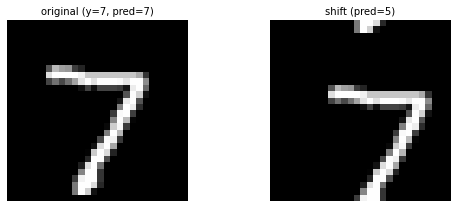

In [6]:

def shift_image(x, dx=2, dy=2):
    if x.ndim == 3:
        img = x[...,0]
    else:
        img = x
    out = np.roll(np.roll(img, dy, axis=0), dx, axis=1)
    return out[...,None].astype(np.float32)

i = 0
img = x_test[i]
ytrue = int(y_test[i])

img_s = shift_image(img, dx=3, dy=3)

p1 = int(mnist_model.predict(img[None,...], verbose=0).argmax())
p2 = int(mnist_model.predict(img_s[None,...], verbose=0).argmax())

show_row([img, img_s],
         [f"original (y={ytrue}, pred={p1})", f"shift (pred={p2})"],
         cmap="gray", figsize=(8,3))


## A5) Rotación (sensibilidad)

**Qué haremos:** Rotamos imágenes y medimos cómo cambia el **accuracy** del modelo al aumentar el ángulo.


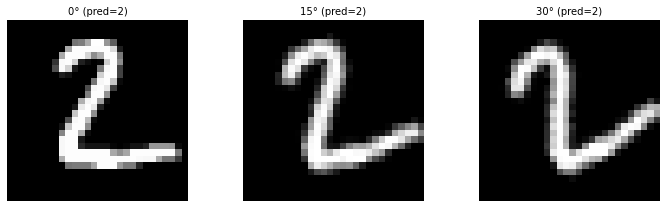

ytrue: 2


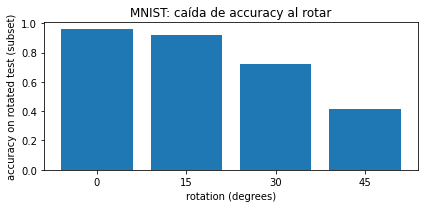

,degrees,accuracy
0,0,0.9578
1,15,0.9190
2,30,0.7206
3,45,0.4142


In [7]:
# Rotamos una imagen (TF/Keras) y medimos cómo cae el accuracy en el test rotado.

def rotate_batch(images, degrees):
    """Rota un batch (N,H,W,C) un ángulo fijo 'degrees'. Devuelve float32."""
    images = tf.convert_to_tensor(images, dtype=tf.float32)
    radians = degrees * np.pi / 180.0
    try:
        import tensorflow_addons as tfa
        return tfa.image.rotate(images, radians, fill_mode="constant", fill_value=0.0).numpy().astype(np.float32)
    except Exception:
        # Fallback: RandomRotation con rango fijo (min=max) -> ángulo fijo
        layer = layers.RandomRotation(factor=(degrees/360.0, degrees/360.0), fill_mode="constant")
        return layer(images, training=True).numpy().astype(np.float32)

def accuracy_on_rotated_test(model, degrees, max_n=5000, batch_size=256):
    """Evalúa accuracy en un subset del test rotado (para que sea rápido en clase)."""
    x_sub = x_test[:max_n]
    y_sub = y_test[:max_n]
    x_rot = rotate_batch(x_sub, degrees)
    loss, acc = model.evaluate(x_rot, y_sub, verbose=0, batch_size=batch_size)
    return float(acc)

# --- 1) Demo visual (una imagen) ---
i = 1
img = x_test[i]
ytrue = int(y_test[i])

img_r15 = rotate_batch(img[None,...], 15)[0]
img_r30 = rotate_batch(img[None,...], 30)[0]

p0  = int(mnist_model.predict(img[None,...], verbose=0).argmax())
p15 = int(mnist_model.predict(img_r15[None,...], verbose=0).argmax())
p30 = int(mnist_model.predict(img_r30[None,...], verbose=0).argmax())

show_row([img, img_r15, img_r30],
         [f"0° (pred={p0})", f"15° (pred={p15})", f"30° (pred={p30})"],
         cmap="gray", figsize=(10,3))
print("ytrue:", ytrue)

# --- 2) Efecto en accuracy (test rotado) ---
angles = [0, 15, 30, 45]
accs = [accuracy_on_rotated_test(mnist_model, a, max_n=5000) for a in angles]

plt.figure(figsize=(6,3))
plt.bar([str(a) for a in angles], accs)
plt.xlabel("rotation (degrees)")
plt.ylabel("accuracy on rotated test (subset)")
plt.title("MNIST: caída de accuracy al rotar")
plt.tight_layout()
plt.show()

pd.DataFrame({"degrees": angles, "accuracy": accs})



### A5.1) (Opcional) Entrenar rápido con augmentation y repetir rotación

**Qué haremos:** Entrenamos otro modelo con **data augmentation** (rotación/traslación) y repetimos la evaluación para comparar robustez.


Cambia `RUN_AUG = True` para ejecutarlo.

Epoch 1/3
157/157 [==============================] - 10s 50ms/step - loss: 1.0263 - accuracy: 0.6744 - val_loss: 0.2124 - val_accuracy: 0.9360
Epoch 2/3
157/157 [==============================] - 8s 48ms/step - loss: 0.3909 - accuracy: 0.8792 - val_loss: 0.1597 - val_accuracy: 0.9506
Epoch 3/3
157/157 [==============================] - 8s 49ms/step - loss: 0.2927 - accuracy: 0.9096 - val_loss: 0.1311 - val_accuracy: 0.9584
Aug model test acc: 0.961


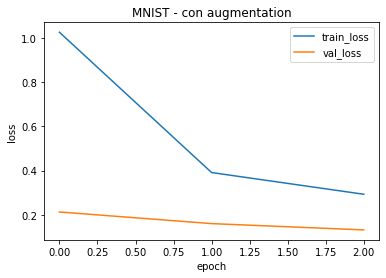

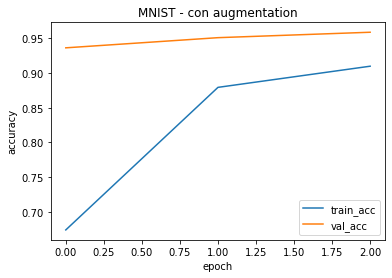

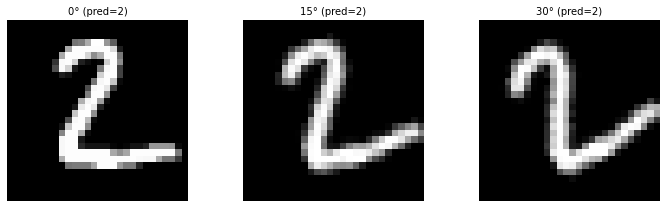

ytrue: 2


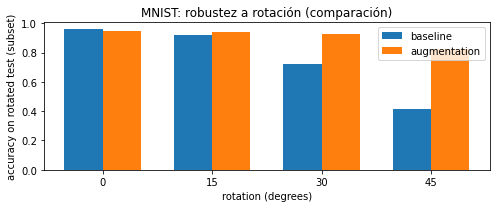

In [10]:

RUN_AUG = True

def build_mnist_aug_cnn(filters=16, kernel=3):
    inp = keras.Input(shape=(28,28,1))
    x = keras.Sequential([
        layers.RandomRotation(0.12),
        layers.RandomTranslation(0.08, 0.08),
    ])(inp)
    x = layers.Conv2D(filters, kernel, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(filters*2, kernel, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(10, activation="softmax")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

if RUN_AUG:
    aug_model = build_mnist_aug_cnn()
    h_aug = aug_model.fit(x_tr_s, y_tr_s, validation_data=(x_val_s, y_val_s),
                          epochs=3, batch_size=128, verbose=1)
    te_loss, te_acc = aug_model.evaluate(x_test, y_test, verbose=0)
    print("Aug model test acc:", round(float(te_acc), 4))
    plot_history(h_aug, title="MNIST - con augmentation")

    i = 1
    img = x_test[i]
    ytrue = int(y_test[i])
    img_r15 = rotate_batch(img, 15)
    img_r30 = rotate_batch(img, 30)

    p0  = int(aug_model.predict(img[None,...], verbose=0).argmax())
    p15 = int(aug_model.predict(img_r15[None,...], verbose=0).argmax())
    p30 = int(aug_model.predict(img_r30[None,...], verbose=0).argmax())

    show_row([img, img_r15, img_r30],
             [f"0° (pred={p0})", f"15° (pred={p15})", f"30° (pred={p30})"],
             cmap="gray", figsize=(10,3))
    print("ytrue:", ytrue)


    # --- Comparación de robustez a rotación (baseline vs augmentation) ---
    angles = [0, 15, 30, 45]
    acc_base = [accuracy_on_rotated_test(mnist_model, a, max_n=5000) for a in angles]
    acc_aug  = [accuracy_on_rotated_test(aug_model,  a, max_n=5000) for a in angles]

    df_rot = pd.DataFrame({"degrees": angles, "baseline_acc": acc_base, "augmented_acc": acc_aug})
    df_rot

    plt.figure(figsize=(7,3))
    x = np.arange(len(angles))
    w = 0.35
    plt.bar(x - w/2, acc_base, width=w, label="baseline")
    plt.bar(x + w/2, acc_aug,  width=w, label="augmentation")
    plt.xticks(x, [str(a) for a in angles])
    plt.xlabel("rotation (degrees)")
    plt.ylabel("accuracy on rotated test (subset)")
    plt.title("MNIST: robustez a rotación (comparación)")
    plt.legend()
    plt.tight_layout()
    plt.show()


## A6) Occlusion sensitivity (qué zona importa)

**Qué haremos:** Aplicamos **occlusion sensitivity**: tapamos parches y vemos qué zonas son más importantes.


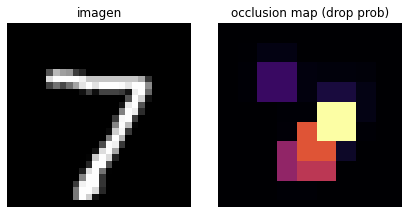

In [11]:

def occlusion_map(model, img, true_class, patch=6, stride=3):
    H, W, C = img.shape
    base = model.predict(img[None,...], verbose=0)[0, true_class]
    heat = np.zeros((H, W), dtype=np.float32)

    for y in range(0, H-patch+1, stride):
        for x in range(0, W-patch+1, stride):
            tmp = img.copy()
            tmp[y:y+patch, x:x+patch, :] = 0.0
            score = model.predict(tmp[None,...], verbose=0)[0, true_class]
            drop = base - score
            heat[y:y+patch, x:x+patch] = np.maximum(heat[y:y+patch, x:x+patch], drop)

    heat = heat / (heat.max() + 1e-8)
    return heat

i = 0
img = x_test[i]
ytrue = int(y_test[i])
heat = occlusion_map(mnist_model, img, ytrue, patch=6, stride=3)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(img[...,0], cmap="gray"); plt.axis("off"); plt.title("imagen")

plt.subplot(1,2,2)
plt.imshow(heat, cmap="inferno"); plt.axis("off"); plt.title("occlusion map (drop prob)")

plt.tight_layout()
plt.show()


## A7) Pooling vs Stride2 (downsampling)

**Qué haremos:** Comparamos **pooling** vs **stride=2** (downsampling aprendido) midiendo accuracy y parámetros.


In [12]:

def train_quick(model, epochs=3):
    h = model.fit(x_tr_s, y_tr_s, validation_data=(x_val_s, y_val_s),
                  epochs=epochs, batch_size=128, verbose=0)
    te_acc = float(model.evaluate(x_test, y_test, verbose=0)[1])
    val_best = float(max(h.history["val_accuracy"]))
    return te_acc, val_best, int(model.count_params())

m_pool   = build_mnist_cnn(filters=16, kernel=3, use_pool=True, use_stride_downsample=False)
m_stride = build_mnist_cnn(filters=16, kernel=3, use_pool=False, use_stride_downsample=True)

acc_pool, val_pool, p_pool = train_quick(m_pool, epochs=3)
acc_str,  val_str,  p_str  = train_quick(m_stride, epochs=3)

pd.DataFrame([
    {"variant":"pooling", "val_best":val_pool, "test_acc":acc_pool, "params":p_pool},
    {"variant":"stride2", "val_best":val_str,  "test_acc":acc_str,  "params":p_str},
])


,variant,val_best,test_acc,params
0,pooling,0.9726,0.9742,105866
1,stride2,0.9732,0.9740,117434


## A8) Capacidad: más filtros (ablation rápida)

**Qué haremos:** Probamos más/menos filtros para ver el efecto de la **capacidad** del modelo en el accuracy.


In [13]:

variants = []
for f in [8, 16, 32]:
    m = build_mnist_cnn(filters=f, kernel=3, use_pool=True)
    acc, vbest, params = train_quick(m, epochs=3)
    variants.append({"filters": f, "test_acc": acc, "val_best": vbest, "params": params})

df_cap = pd.DataFrame(variants).sort_values("test_acc", ascending=False)
df_cap


,filters,test_acc,val_best,params
2,32,0.9795,0.9758,220234
1,16,0.9698,0.9700,105866
0,8,0.9675,0.9680,52138


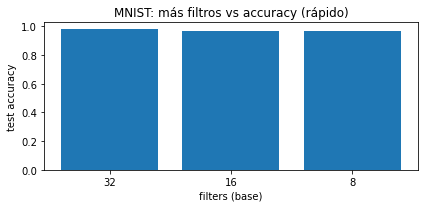

,filters,test_acc,val_best,params
0,32,0.9795,0.9758,220234
1,16,0.9698,0.9700,105866
2,8,0.9675,0.9680,52138


In [14]:

plt.figure(figsize=(6,3))
plt.bar([str(x) for x in df_cap["filters"]], df_cap["test_acc"])
plt.xlabel("filters (base)")
plt.ylabel("test accuracy")
plt.title("MNIST: más filtros vs accuracy (rápido)")
plt.tight_layout()
plt.show()
display(df_cap.reset_index(drop=True))


## A9) Overfitting show: 2k vs 20k ejemplos

**Qué haremos:** Demostración de **overfitting**: mismo modelo con 2k vs 20k ejemplos y comparamos curvas/accuracy.


Test acc (2k): 0.9364
Test acc (20k): 0.9843


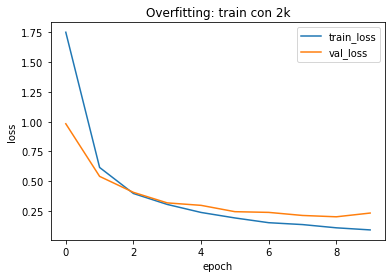

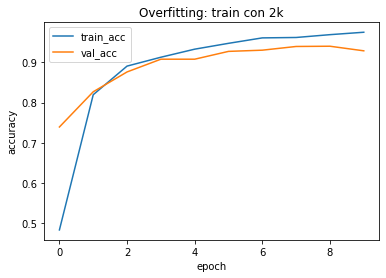

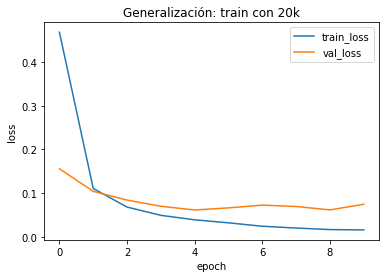

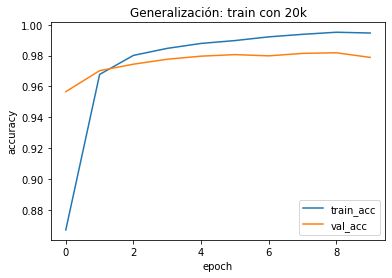

In [15]:

def train_with_n(n_train, epochs=10):
    m = build_mnist_cnn(filters=32, kernel=3, use_pool=True)
    x_small, y_small = x_tr[:n_train], y_tr[:n_train]
    h = m.fit(x_small, y_small, validation_data=(x_val_s, y_val_s),
              epochs=epochs, batch_size=128, verbose=1)
    te_acc = float(m.evaluate(x_test, y_test, verbose=0)[1])
    return m, h, te_acc

m_2k, h_2k, acc_2k = train_with_n(2000, epochs=10)
m_20k, h_20k, acc_20k = train_with_n(20000, epochs=10)

print("Test acc (2k):", round(acc_2k,4))
print("Test acc (20k):", round(acc_20k,4))

plot_history(h_2k, title="Overfitting: train con 2k")
plot_history(h_20k, title="Generalización: train con 20k")


## A10) Parámetros: MLP vs CNN

**Qué haremos:** Comparamos una **MLP** vs una **CNN**: parámetros y rendimiento (por qué CNN escala mejor).


In [16]:

def build_mlp_mnist(hidden=256):
    inp = keras.Input(shape=(28,28,1))
    x = layers.Flatten()(inp)
    x = layers.Dense(hidden, activation="relu")(x)
    x = layers.Dense(hidden, activation="relu")(x)
    out = layers.Dense(10, activation="softmax")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

mlp = build_mlp_mnist(hidden=256)
cnn = build_mnist_cnn(filters=16, kernel=3, use_pool=True)

print("MLP params:", mlp.count_params())
print("CNN params:", cnn.count_params())

def train_eval(m, epochs=3):
    m.fit(x_tr_s, y_tr_s, validation_data=(x_val_s, y_val_s),
          epochs=epochs, batch_size=128, verbose=0)
    return float(m.evaluate(x_test, y_test, verbose=0)[1])

acc_mlp = train_eval(mlp, epochs=3)
acc_cnn = train_eval(cnn, epochs=3)

pd.DataFrame([
    {"model":"MLP", "params": mlp.count_params(), "test_acc": acc_mlp},
    {"model":"CNN", "params": cnn.count_params(), "test_acc": acc_cnn},
])


MLP params: 269322
CNN params: 105866


,model,params,test_acc
0,MLP,269322,0.9523
1,CNN,105866,0.9750



## A11) (Educativo) FGSM adversarial en MNIST

**Qué haremos:** Ejemplo educativo de **FGSM adversarial**: perturbación pequeña que puede cambiar la predicción.


Pequeña perturbación dirigida por gradiente que puede cambiar la predicción.

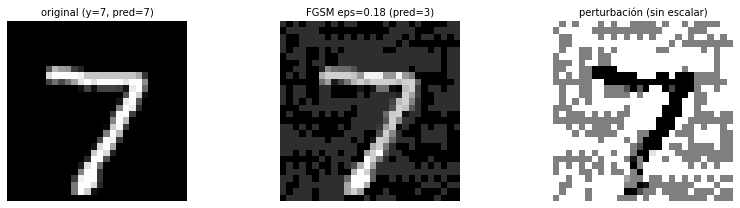

In [17]:

loss_fn = keras.losses.SparseCategoricalCrossentropy()

def fgsm_attack(model, x, y, eps=0.18):
    x_tf = tf.convert_to_tensor(x[None,...])
    y_tf = tf.convert_to_tensor([y])

    with tf.GradientTape() as tape:
        tape.watch(x_tf)
        pred = model(x_tf, training=False)
        loss = loss_fn(y_tf, pred)

    grad = tape.gradient(loss, x_tf)
    signed = tf.sign(grad)
    x_adv = tf.clip_by_value(x_tf + eps * signed, 0.0, 1.0)
    return x_adv.numpy()[0]

i = 0
img = x_test[i]
ytrue = int(y_test[i])

p0 = int(mnist_model.predict(img[None,...], verbose=0).argmax())
img_adv = fgsm_attack(mnist_model, img, ytrue, eps=0.18)
p1 = int(mnist_model.predict(img_adv[None,...], verbose=0).argmax())

pert = img_adv - img

show_row([img, img_adv, pert],
         [f"original (y={ytrue}, pred={p0})", f"FGSM eps=0.18 (pred={p1})", "perturbación (sin escalar)"],
         cmap="gray", figsize=(12,3))



# Parte B — CIFAR-10 (opcional)

Incluye:
- baseline CNN con augmentation
- filtros RGB de la primera conv
- Grad-CAM básico

Activa `RUN_CIFAR = True` para ejecutarlo.

In [ ]:

RUN_CIFAR = False


In [ ]:

if RUN_CIFAR:
    from tensorflow.keras.datasets import cifar10

    (xc_tr, yc_tr), (xc_te, yc_te) = cifar10.load_data()
    yc_tr = yc_tr.squeeze()
    yc_te = yc_te.squeeze()

    xc_tr = xc_tr.astype("float32")/255.0
    xc_te = xc_te.astype("float32")/255.0

    val_size = 5000
    xc_val, yc_val = xc_tr[-val_size:], yc_tr[-val_size:]
    xc_tr2, yc_tr2 = xc_tr[:-val_size], yc_tr[:-val_size]

    CIFAR10_CLASS_NAMES = [
        "airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"
    ]

    idx = np.random.default_rng(SEED).choice(len(xc_tr2), size=12, replace=False)
    show_row([xc_tr2[i] for i in idx],
             [CIFAR10_CLASS_NAMES[int(yc_tr2[i])] for i in idx],
             figsize=(12,3))


In [ ]:

if RUN_CIFAR:
    def build_cifar_cnn():
        inp = keras.Input(shape=(32,32,3))
        x = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.08),
            layers.RandomZoom(0.1),
        ])(inp)

        x = layers.Conv2D(32, 3, padding="same", activation="relu", name="cifar_conv1")(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)

        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(128, activation="relu")(x)
        out = layers.Dense(10, activation="softmax")(x)

        m = keras.Model(inp, out)
        m.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
        return m

    cifar_model = build_cifar_cnn()
    cifar_model.summary()

    xc_tr_s, yc_tr_s = xc_tr2[:30000], yc_tr2[:30000]
    xc_val_s, yc_val_s = xc_val[:5000], yc_val[:5000]

    h = cifar_model.fit(xc_tr_s, yc_tr_s, validation_data=(xc_val_s, yc_val_s),
                        epochs=8, batch_size=128, verbose=1)

    te_acc = float(cifar_model.evaluate(xc_te, yc_te, verbose=0)[1])
    print("CIFAR test acc:", round(te_acc,4))
    plot_history(h, title="CIFAR-10 baseline")


## B1) Filtros RGB de la primera conv (CIFAR)

**Qué haremos:** Mostramos filtros de la primera conv en CIFAR (son kernels **RGB**, no 2D).


In [ ]:

if RUN_CIFAR:
    W, b = cifar_model.get_layer("cifar_conv1").get_weights()
    print("W shape:", W.shape)  # (k,k,3,out_ch)

    n_filters = min(W.shape[-1], 16)
    imgs, titles = [], []
    for i in range(n_filters):
        f = W[:,:,:,i]
        f2 = f - f.min()
        if f2.max() > 0:
            f2 = f2 / f2.max()
        imgs.append(f2)
        titles.append(f"f{i}")

    show_row(imgs, titles, figsize=(14,3))


## B2) Grad-CAM (CIFAR) básico

**Qué haremos:** Generamos un **Grad-CAM** básico para ver ‘dónde mira’ la red en una predicción.


In [ ]:

if RUN_CIFAR:
    last_conv_name = None
    for layer in reversed(cifar_model.layers):
        if isinstance(layer, layers.Conv2D):
            last_conv_name = layer.name
            break
    print("Last conv:", last_conv_name)

    grad_model = keras.Model(
        [cifar_model.inputs],
        [cifar_model.get_layer(last_conv_name).output, cifar_model.output]
    )

    def gradcam_heatmap(img, class_idx=None):
        img_tf = tf.convert_to_tensor(img[None,...])
        with tf.GradientTape() as tape:
            conv_out, preds = grad_model(img_tf, training=False)
            if class_idx is None:
                class_idx = tf.argmax(preds[0])
            loss = preds[:, class_idx]

        grads = tape.gradient(loss, conv_out)
        pooled = tf.reduce_mean(grads, axis=(0,1,2))
        conv_out = conv_out[0]
        heat = tf.reduce_sum(conv_out * pooled, axis=-1)

        heat = tf.maximum(heat, 0)
        heat = heat / (tf.reduce_max(heat) + 1e-8)
        return heat.numpy(), int(class_idx.numpy())

    i = 0
    img = xc_te[i]
    ytrue = int(yc_te[i])
    preds = cifar_model.predict(img[None,...], verbose=0)[0]
    ypred = int(np.argmax(preds))

    heat, _ = gradcam_heatmap(img, class_idx=ypred)
    heat_resized = tf.image.resize(heat[...,None], (32,32)).numpy()[...,0]
    overlay = img * 0.6 + np.stack([heat_resized]*3, axis=-1) * 0.4
    overlay = np.clip(overlay, 0, 1)

    show_row(
        [img, heat_resized, overlay],
        [f"img (true={CIFAR10_CLASS_NAMES[ytrue]}, pred={CIFAR10_CLASS_NAMES[ypred]})", "heatmap", "overlay"],
        figsize=(12,3)
    )



# Cierre: preguntas para debate

- ¿Qué “pierde” el pooling? ¿Cuándo conviene evitarlo?
- ¿Por qué augmentation mejora invariancias?
- ¿Hasta qué punto una CNN “entiende” vs memoriza?
- ¿Qué implicaciones tiene la vulnerabilidad adversarial?